In [3]:
import spacy
import pandas as pd
import spacy.lang.yo as yo
from spacy.lang.yo.stop_words import STOP_WORDS as yor_sw
from spacy.lang.en.stop_words import STOP_WORDS as en_sw
import numpy as np
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.models import Word2Vec

In [2]:
nlp = spacy.blank('yo')
text = "Mo fẹ lọ si ọjà lati ra eso ati akara."

for token in nlp(text):
    print(token)

Mo
fẹ
lọ
si
ọjà
lati
ra
eso
ati
akara
.


In [34]:
yor_df1 = pd.read_csv("train.tsv", sep="\t")
# yor_df2 = pd.read_csv('yoruba_dataset.csv')
yor_df2 = pd.read_csv('yoruba_sentiment_noisy_5k.csv')
yor_df3 = pd.read_csv("test.tsv", sep="\t")
yor_df4 = pd.read_csv("dev.tsv", sep="\t")
yor_df5 = pd.read_csv('yoruba_dataset.csv')
yor_df = pd.concat([yor_df2,yor_df1, yor_df3,yor_df4,yor_df5])
yor_df.head()

,tweet,label
0,Bae you try gan.,positive
1,Mo gbádùn rẹ.,positive
2,O ṣeun gan ni o.,positive
3,Ẹ ṣe o.,positive
4,Ìfẹ́ rẹ̀ dá mi lórí.,positive


In [35]:
yor_df.label.value_counts(normalize=True)

label
positive    0.386039
neutral     0.351176
negative    0.262785
Name: proportion, dtype: float64

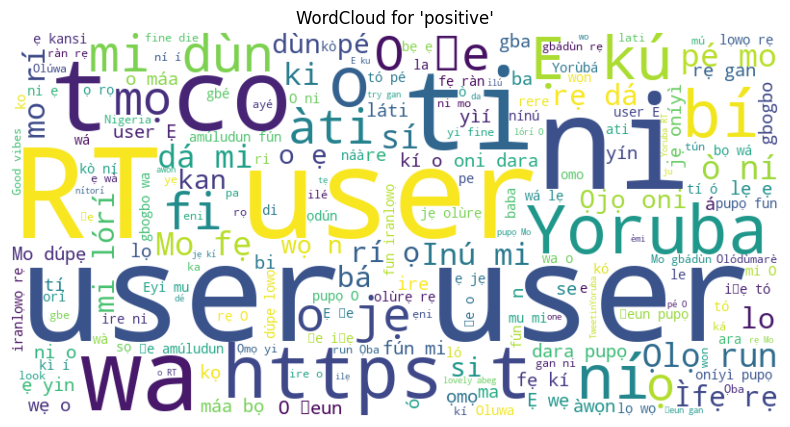

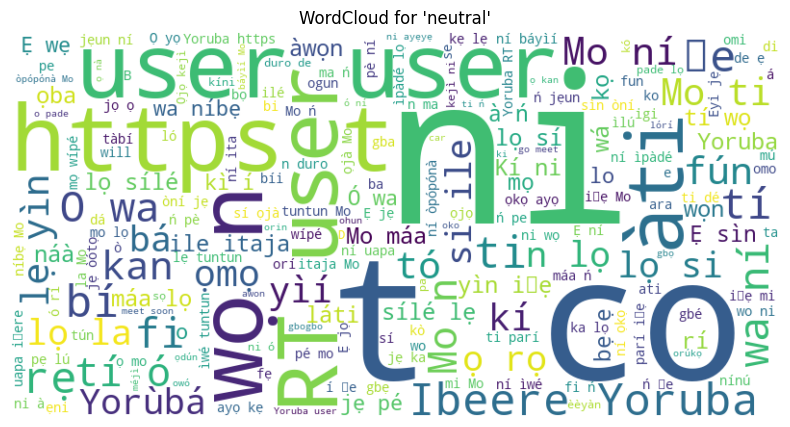

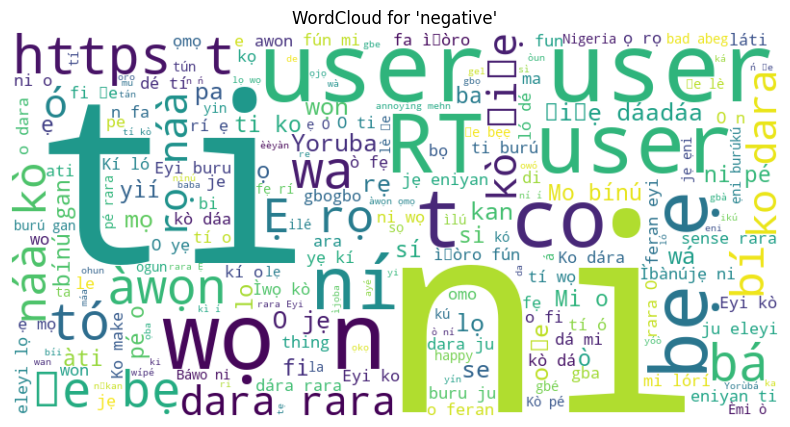

In [36]:
for label in yor_df["label"].unique():
    text = " ".join(yor_df[yor_df["label"] == label]["tweet"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

In [2]:
yorsw = pd.read_csv('yor.csv')
def preprocess_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    
    text = re.sub(r'http\S+|@\w+|#\w+|\bRT\b|"{2,}', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[.]{2,}', ' ', text)
    text = re.sub(r'[\!\?\.\,]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    doc = nlp(text)
    tokens = [
        token.text.lower() for token in doc 
        if token.text.lower() not in yorsw.word  or en_sw
        and token.text not in string.punctuation
        and len(token.text.strip()) > 1
        and not token.text.isdigit()
    ]

    return " ".join(tokens).strip() or "empty"

NameError: name 'pd' is not defined

In [53]:
yor_df['clean_text'] = yor_df.tweet.apply(preprocess_text)

In [54]:
yor_df.head()

,tweet,label,clean_text,new_label
0,Bae you try gan.,positive,bae you try gan,2
1,Mo gbádùn rẹ.,positive,mo gbádùn rẹ,2
2,O ṣeun gan ni o.,positive,ṣeun gan ni,2
3,Ẹ ṣe o.,positive,ṣe,2
4,Ìfẹ́ rẹ̀ dá mi lórí.,positive,ìfẹ́ rẹ̀ dá mi lórí,2


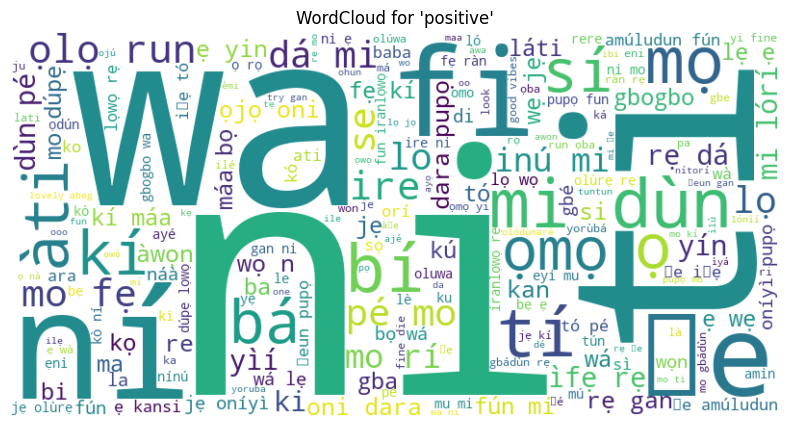

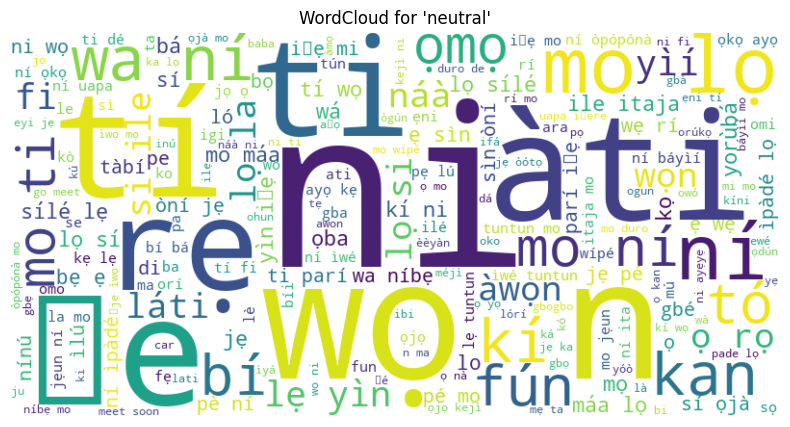

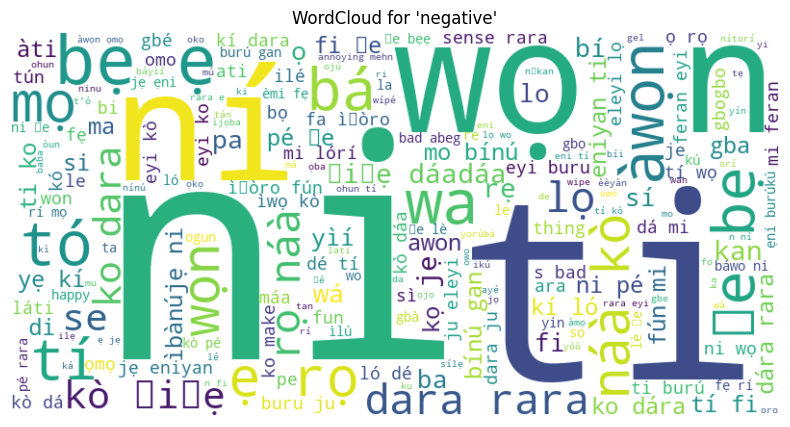

In [41]:
for label in yor_df["label"].unique():
    text = " ".join(yor_df[yor_df["label"] == label]["clean_text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

In [42]:
yor_df.label.value_counts()

label
positive    9700
neutral     8824
negative    6603
Name: count, dtype: int64

<Axes: ylabel='count'>

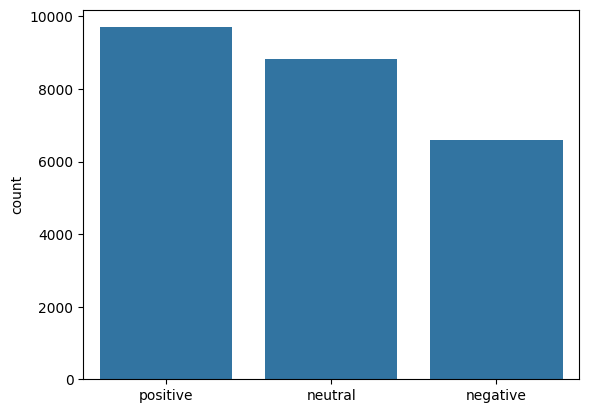

In [43]:
seaborn.countplot(x=yor_df.label.values)

In [44]:
labels = {'negative' : 0, 'neutral' : 1, 'positive' : 2}

yor_df['new_label'] = yor_df.label.map(labels)
yor_df.head()

,tweet,label,clean_text,new_label
0,Bae you try gan.,positive,bae you try gan,2
1,Mo gbádùn rẹ.,positive,mo gbádùn rẹ,2
2,O ṣeun gan ni o.,positive,ṣeun gan ni,2
3,Ẹ ṣe o.,positive,ṣe,2
4,Ìfẹ́ rẹ̀ dá mi lórí.,positive,ìfẹ́ rẹ̀ dá mi lórí,2


In [45]:
count_positive,count_neutral,count_negative = yor_df.label.value_counts()

In [46]:
df_class_negative = yor_df[yor_df['label']== 'negative'] 
df_class_positive = yor_df[yor_df['label']== 'positive']
df_class_neutral = yor_df[yor_df['label']== 'neutral']

In [47]:
# df_class_worry_over = df_class_negative.sample(count_neutral, replace=True)
df_class_neutral_over = df_class_neutral.sample(count_positive, replace=True)
df_class_negative_over = df_class_negative.sample(count_positive, replace=True)

oversampled_data = pd.concat([df_class_neutral_over, df_class_negative_over, df_class_positive])
print(oversampled_data.label.value_counts())

label
neutral     9700
negative    9700
positive    9700
Name: count, dtype: int64


In [48]:
oversampled_data.head()

,tweet,label,clean_text,new_label
3799,A o pade lọ́la.,neutral,pade lọ́la,1
516,"Ẹ jọ̀ọ́, mo n duro de ẹ.",neutral,jọ̀ọ́ mo duro de,1
2250,malaolu mu ala fun olu,neutral,malaolu mu ala fun olu,1
1054,We go meet soon.,neutral,we go meet soon,1
2721,RT @user: @user Lateteji. owo nije mo ba o tan...,neutral,lateteji owo nije mo ba tan osi ni je talo mo ri,1


In [ ]:
def tokenize(text):
    return text.split()  # already cleaned earlier

# Train Word2Vec on your oversampled data
tokenized_sentences = [tokenize(t) for t in oversampled_data['clean_text']]

w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)
w2v_model.save("yoruba_word2vec.model")

In [ ]:
class Word2VecVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, model_path):
        self.model_path = model_path
        self.model = None

    def fit(self, X, y=None):
        from gensim.models import Word2Vec
        self.model = Word2Vec.load(self.model_path)
        return self

    def transform(self, X):
        vectors = []
        for sentence in X:
            tokens = sentence.split()
            vecs = [self.model.wv[w] for w in tokens if w in self.model.wv]
            if vecs:
                vectors.append(np.mean(vecs, axis=0))
            else:
                vectors.append(np.zeros(self.model.vector_size))
        return np.array(vectors)

In [51]:
x_train, x_test, y_train, y_test = train_test_split(oversampled_data['clean_text'], oversampled_data['new_label'], test_size=0.2)

In [25]:
ran_model = Pipeline([
    ('w2v', Word2VecVectorizer("yoruba_word2vec.model")),
    ('rand', RandomForestClassifier(n_estimators=100, criterion='gini'))
])


ran_model.fit(x_train, y_train)

,steps,"[('w2v', ...), ('rand', ...)]"
,transform_input,None
,memory,None
,verbose,False
,model_path,'yoruba_word2vec.model'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [26]:
rand_ypred = ran_model.predict(x_test)

print(classification_report(y_test, rand_ypred))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1070
           1       0.85      0.87      0.86      1046
           2       0.82      0.83      0.82      1010

    accuracy                           0.86      3126
   macro avg       0.86      0.86      0.86      3126
weighted avg       0.86      0.86      0.86      3126



In [ ]:
# f1 = f1_score(y_test, rand_ypred, average='weighted')
# precision = precision_score(y_test, rand_ypred, average='weighted')
# recall = recall_score(y_test, rand_ypred, average='weighted')
# accuracy = accuracy_score(y_test, rand_ypred)

# print("Rand Forest Classifier Model Evaluation")
# print("Accuracy score:", "{:.2f}".format(round(accuracy, 2)))
# print("F1 score:", "{:.2f}".format(round(f1, 2)))
# print("Precision score:", "{:.2f}".format(round(precision, 2)))
# print("Recall score:", "{:.2f}".format(round(recall, 2)))

Rand Forest Classifier Model Evaluation
Accuracy score: 0.86
F1 score: 0.86
Precision score: 0.86
Recall score: 0.86


In [28]:
mlp_model = Pipeline([
    ('w2v', Word2VecVectorizer("yoruba_word2vec.model")),
    ('mlp', MLPClassifier(max_iter=500))
])


mlp_model.fit(x_train, y_train)

,steps,"[('w2v', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,model_path,'yoruba_word2vec.model'
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'


In [29]:
xgb_model = Pipeline([
    ('w2v', Word2VecVectorizer("yoruba_word2vec.model")),
    ('cgb', XGBClassifier())
])


xgb_model.fit(x_train, y_train)

,steps,"[('w2v', ...), ('cgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,model_path,'yoruba_word2vec.model'
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [30]:
mlp_ypred = mlp_model.predict(x_test)

print(classification_report(y_test, mlp_ypred))

              precision    recall  f1-score   support

           0       0.78      0.77      0.77      1070
           1       0.75      0.81      0.78      1046
           2       0.79      0.74      0.76      1010

    accuracy                           0.77      3126
   macro avg       0.77      0.77      0.77      3126
weighted avg       0.77      0.77      0.77      3126



In [31]:
xgb_ypred = xgb_model.predict(x_test)

print(classification_report(y_test, xgb_ypred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1070
           1       0.87      0.86      0.87      1046
           2       0.83      0.83      0.83      1010

    accuracy                           0.86      3126
   macro avg       0.86      0.86      0.86      3126
weighted avg       0.86      0.86      0.86      3126



In [33]:
samples = [
    "O ṣeun pupọ fun iranlọwọ rẹ.",   # Positive
    "O jẹ eniyan ti ko dara rara.",     # Negative
    "Mo n lọ si ile itaja.",           # Neutral
    "Ìfẹ́ rẹ̀ dá mi lórí.",            # Positive
    "Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.",       # Negative
    "Ọjọ́ oni dara pupọ.",           # Positive
    "Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.",      # Negative
    "Mo máa lọ sílé lẹ́yìn iṣẹ́.",    # Neutral
    "Inú mi dùn pé mo rí ọ.",          # Positive
    "O yẹ kí o dara ju eleyi lọ.",      # Negative
    'A o pade lọ́la.',
    'Eyi kò dáa.',
    'O wa ní ita.',
    'Eyi ko ye mi.',
    'Mo fẹ́ràn rẹ gan-an.',
    'Mi o feran eyi.',
    'Eyi ko dara rara.',
    'O ṣeun gan ni o.',
    'Ọjọ́ oni dara pupọ.',
    'Mo ti dé.',
    'O ni ẹ̀wà.',
    'O dara rara ni.',
    'Kò pé rara.',
    'Mo fe ki o maa wa.',
    'O wa ní uapa iṣere.'
]


models = {
    "RandomForest": ran_model,
    "MLP": mlp_model,
    "XGBoost": xgb_model
}

for text in samples:
    print(f"\n{text}")
    for name, model in models.items():
        pred = model.predict([text])[0]
        print(f"  {name} -> {pred}")



O ṣeun pupọ fun iranlọwọ rẹ.
  RandomForest -> 2
  MLP -> 0
  XGBoost -> 2

O jẹ eniyan ti ko dara rara.
  RandomForest -> 0
  MLP -> 0
  XGBoost -> 0

Mo n lọ si ile itaja.
  RandomForest -> 1
  MLP -> 1
  XGBoost -> 1

Ìfẹ́ rẹ̀ dá mi lórí.
  RandomForest -> 2
  MLP -> 2
  XGBoost -> 1

Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.
  RandomForest -> 1
  MLP -> 1
  XGBoost -> 1

Ọjọ́ oni dara pupọ.
  RandomForest -> 2
  MLP -> 2
  XGBoost -> 2

Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.
  RandomForest -> 0
  MLP -> 0
  XGBoost -> 0

Mo máa lọ sílé lẹ́yìn iṣẹ́.
  RandomForest -> 1
  MLP -> 1
  XGBoost -> 1

Inú mi dùn pé mo rí ọ.
  RandomForest -> 2
  MLP -> 2
  XGBoost -> 2

O yẹ kí o dara ju eleyi lọ.
  RandomForest -> 2
  MLP -> 2
  XGBoost -> 2

A o pade lọ́la.
  RandomForest -> 2
  MLP -> 1
  XGBoost -> 1

Eyi kò dáa.
  RandomForest -> 1
  MLP -> 1
  XGBoost -> 1

O wa ní ita.
  RandomForest -> 1
  MLP -> 1
  XGBoost -> 1

Eyi ko ye mi.
  RandomForest -> 2
  MLP -> 0
  XGBoost -> 1

Mo fẹ́ràn rẹ gan-an.
  RandomFores